# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The EV Market Dataset](https://www.kaggle.com/datasets/patelris/electric-vehicle-market-and-pricing-dataset-2026/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	


# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ev_market_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


## last Five row

In [4]:
df.tail()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
1995,BMW,i3,2023,Long Range,122665.71,102.1,360.0,92.0,4.21,190.0,...,Hatchback,38.3,1500.0,5,2,Germany,Luxury,66187,3.78,7
1996,Toyota,bZ4X,2024,Performance,66816.55,110.6,367.0,236.3,4.25,181.0,...,Hatchback,23.1,1863.0,4,0,Japan,Premium,11062,3.79,4
1997,Tesla,Model 3,2025,Long Range,49281.26,90.6,325.0,325.6,5.55,167.0,...,Truck,74.6,2920.0,3,3,US,Mid-range,224804,4.10,6
1998,Tesla,Model X,2026,Premium,139665.73,70.7,248.0,330.7,5.07,175.0,...,Coupe,34.8,1500.0,3,2,US,Luxury,165373,3.66,4
1999,BYD,Qin,2025,Premium,47547.88,67.4,246.0,67.2,6.76,156.0,...,Coupe,28.5,1512.0,4,0,China,Mid-range,214113,3.41,4


## Shape of our dataset

In [5]:
df.shape

(2000, 24)

## List out all columns

In [6]:
df.columns

Index(['brand', 'model', 'year', 'variant', 'price_usd',
       'battery_capacity_kwh', 'range_miles', 'charging_speed_kw',
       'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm',
       'drive_type', 'seating_capacity', 'body_type', 'cargo_volume_cubic_ft',
       'weight_kg', 'safety_rating', 'autopilot_level', 'country_of_origin',
       'market_segment', 'annual_sales_units', 'customer_rating',
       'warranty_years'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

brand                     object
model                     object
year                       int64
variant                   object
price_usd                float64
battery_capacity_kwh     float64
range_miles              float64
charging_speed_kw        float64
acceleration_0_60_mph    float64
top_speed_mph            float64
horsepower               float64
torque_nm                float64
drive_type                object
seating_capacity           int64
body_type                 object
cargo_volume_cubic_ft    float64
weight_kg                float64
safety_rating              int64
autopilot_level            int64
country_of_origin         object
market_segment            object
annual_sales_units         int64
customer_rating          float64
warranty_years             int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   object 
 15  carg

## Check Null Value

In [9]:
df.isnull().sum()

brand                    0
model                    0
year                     0
variant                  0
price_usd                0
battery_capacity_kwh     0
range_miles              0
charging_speed_kw        0
acceleration_0_60_mph    0
top_speed_mph            0
horsepower               0
torque_nm                0
drive_type               0
seating_capacity         0
body_type                0
cargo_volume_cubic_ft    0
weight_kg                0
safety_rating            0
autopilot_level          0
country_of_origin        0
market_segment           0
annual_sales_units       0
customer_rating          0
warranty_years           0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024.028500,78873.907150,74.662800,261.825500,155.206300,5.630635,164.884500,665.744000,601.311500,5.747000,46.105850,1886.164500,4.377000,1.124500,129653.592000,3.572045,4.579000
std,1.410561,35296.621782,20.082879,71.028238,80.982301,1.417733,20.781244,267.124838,238.706686,1.045245,19.850264,383.772906,0.661127,0.919469,105775.154465,0.270398,1.218812
min,2020.000000,16394.330000,40.000000,150.000000,50.000000,2.500000,118.000000,150.000000,200.000000,2.000000,15.000000,1500.000000,3.000000,0.000000,656.000000,3.000000,3.000000
25%,2023.000000,52325.920000,58.475000,204.000000,90.975000,4.620000,148.000000,442.750000,391.750000,5.000000,28.175000,1570.000000,4.000000,0.000000,44296.500000,3.380000,4.000000
50%,2024.000000,73013.015000,75.100000,261.000000,132.100000,5.670000,165.000000,683.000000,615.500000,5.000000,41.250000,1740.500000,4.000000,1.000000,111188.000000,3.560000,4.000000
75%,2025.000000,99780.157500,87.550000,310.000000,217.300000,6.770000,181.000000,939.250000,845.000000,7.000000,64.700000,2149.500000,5.000000,2.000000,202496.750000,3.750000,5.000000
max,2026.000000,269775.200000,119.900000,447.000000,349.900000,8.000000,200.000000,1000.000000,988.000000,7.000000,80.000000,3000.000000,5.000000,3.000000,499717.000000,4.510000,8.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

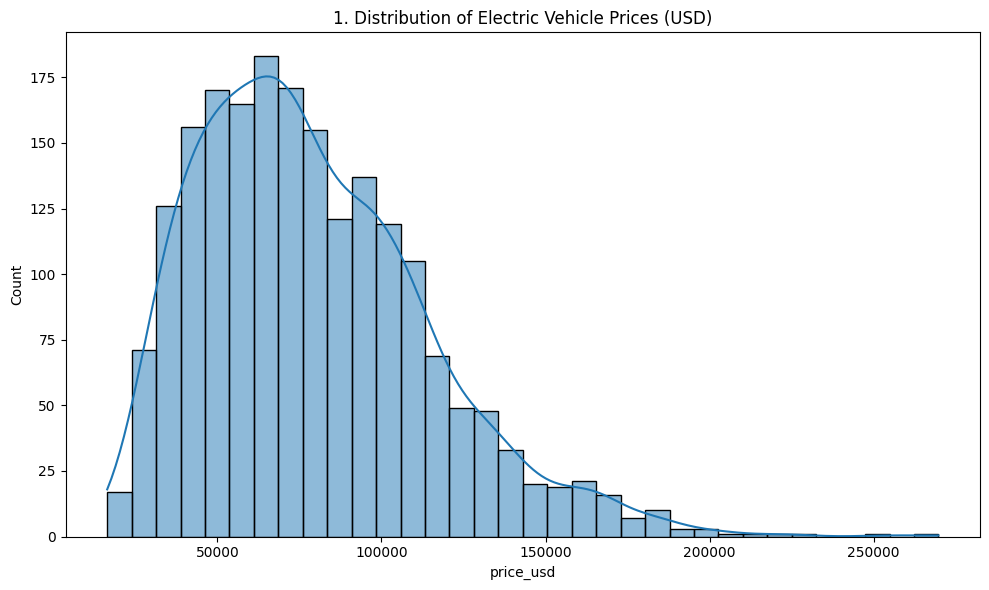

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['price_usd'], kde=True)
plt.title(f'{plot_no}. Distribution of Electric Vehicle Prices (USD)')
show_fig()
plot_no += 1

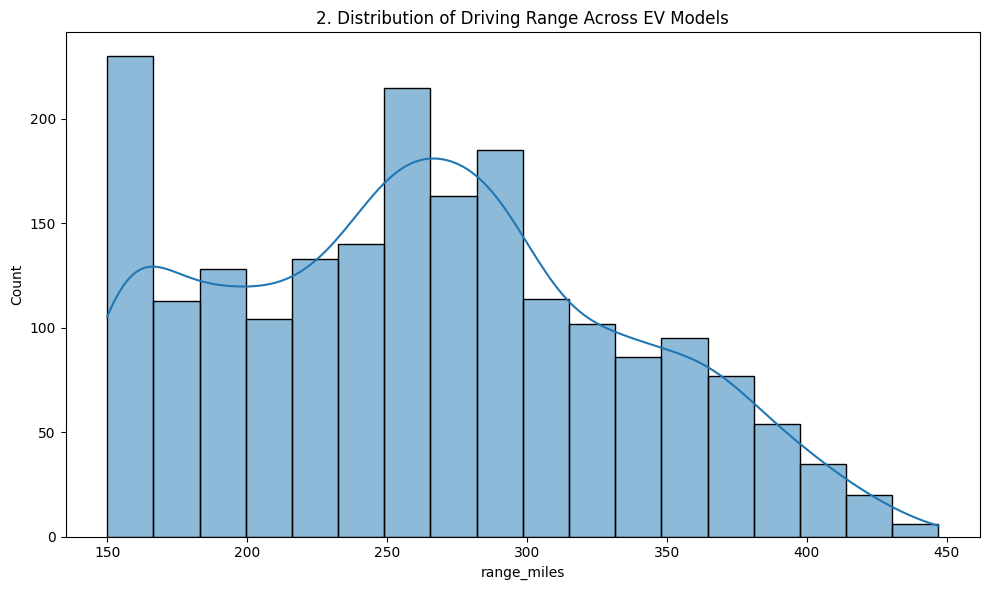

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['range_miles'], kde=True)
plt.title(f'{plot_no}. Distribution of Driving Range Across EV Models')
show_fig()
plot_no += 1

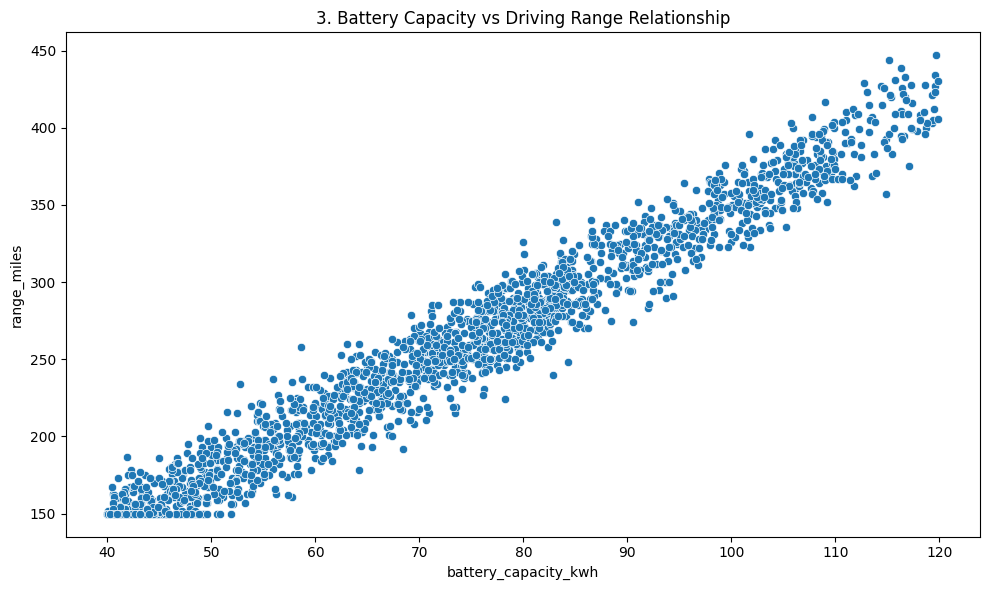

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='battery_capacity_kwh', y='range_miles', data=df)
plt.title(f'{plot_no}. Battery Capacity vs Driving Range Relationship')
show_fig()
plot_no += 1

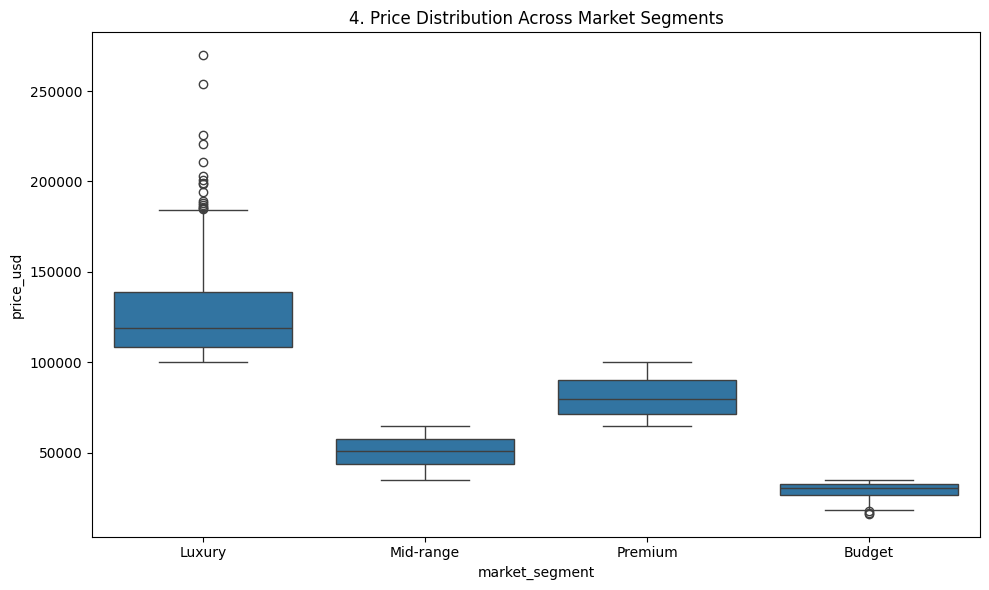

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='market_segment', y='price_usd', data=df)
plt.title(f'{plot_no}. Price Distribution Across Market Segments')
show_fig()
plot_no += 1

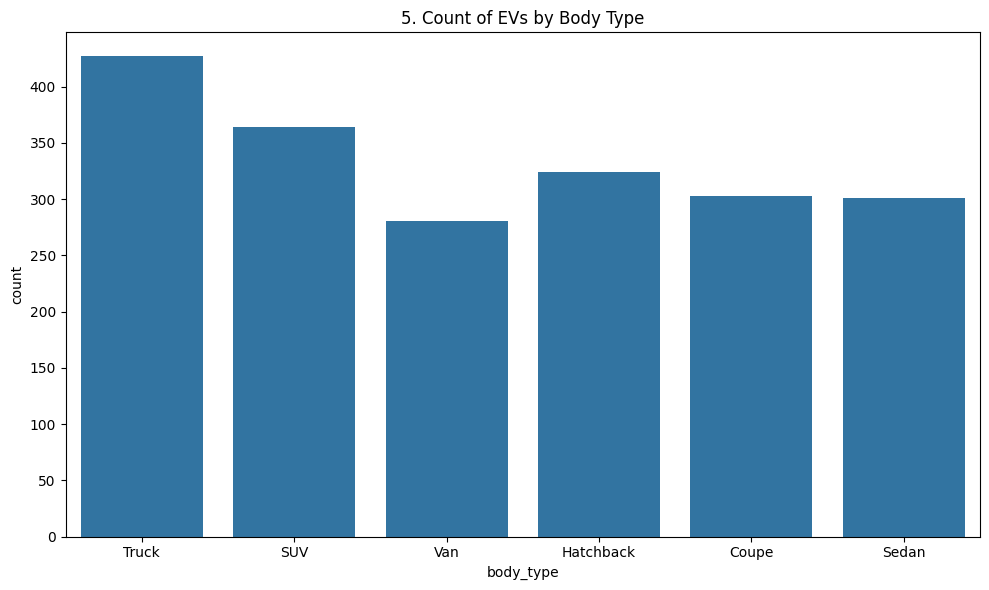

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='body_type', data=df)
plt.title(f'{plot_no}. Count of EVs by Body Type')
show_fig()
plot_no += 1

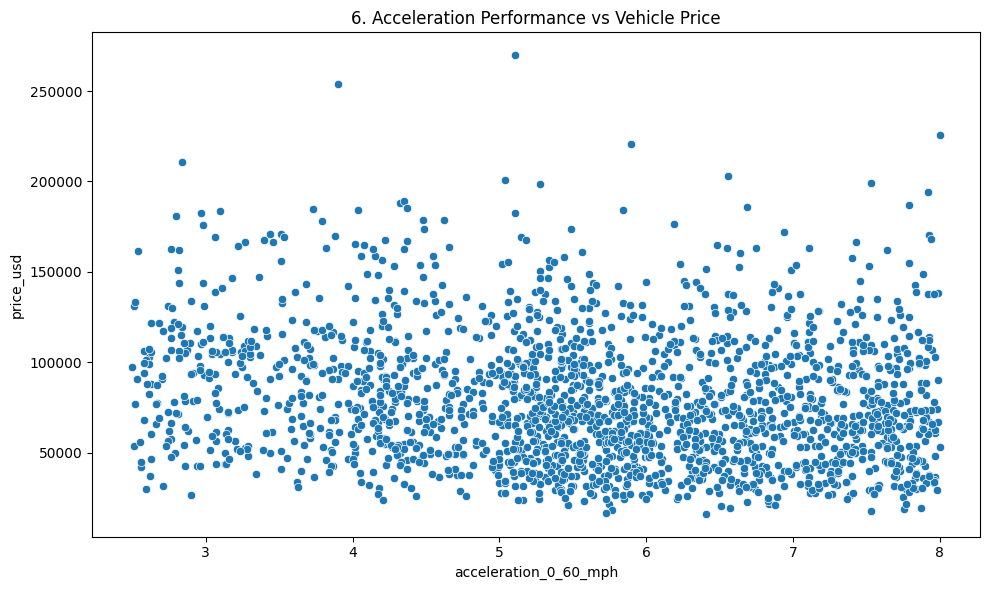

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='acceleration_0_60_mph', y='price_usd', data=df)
plt.title(f'{plot_no}. Acceleration Performance vs Vehicle Price')
show_fig()
plot_no += 1

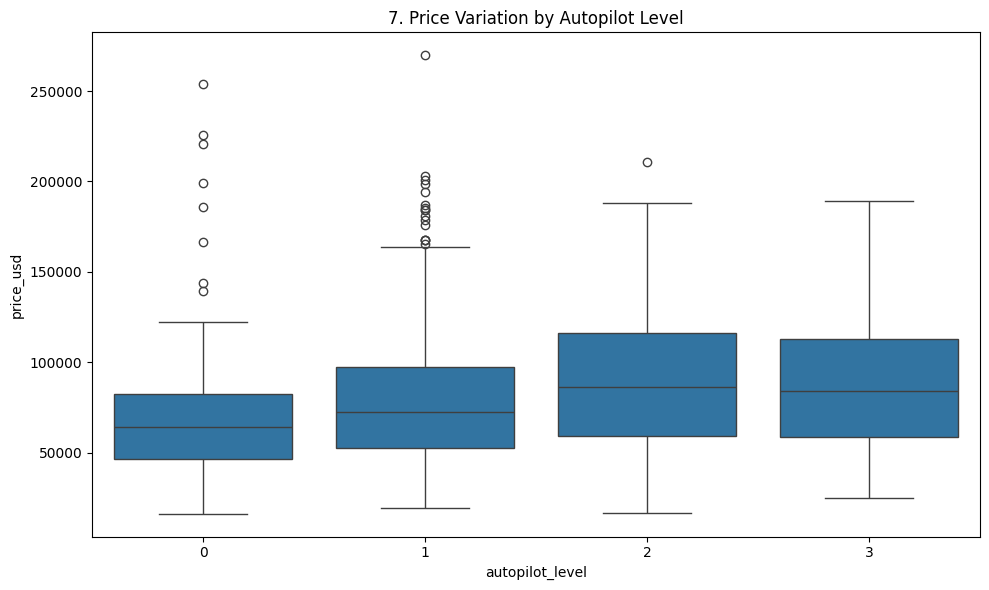

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='autopilot_level', y='price_usd', data=df)
plt.title(f'{plot_no}. Price Variation by Autopilot Level')
show_fig()
plot_no += 1

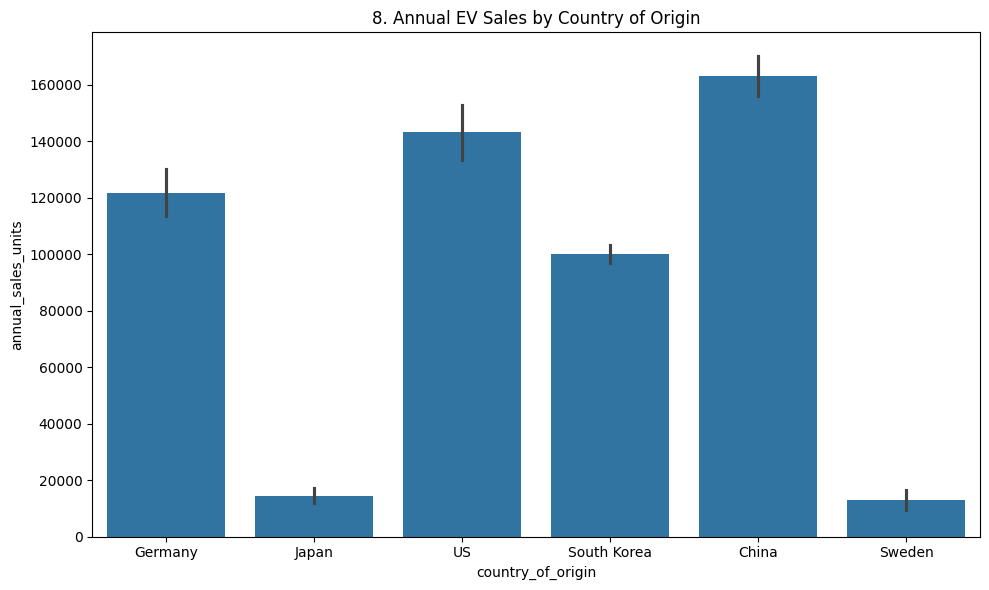

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='country_of_origin', y='annual_sales_units', data=df)
plt.title(f'{plot_no}. Annual EV Sales by Country of Origin')
show_fig()
plot_no += 1

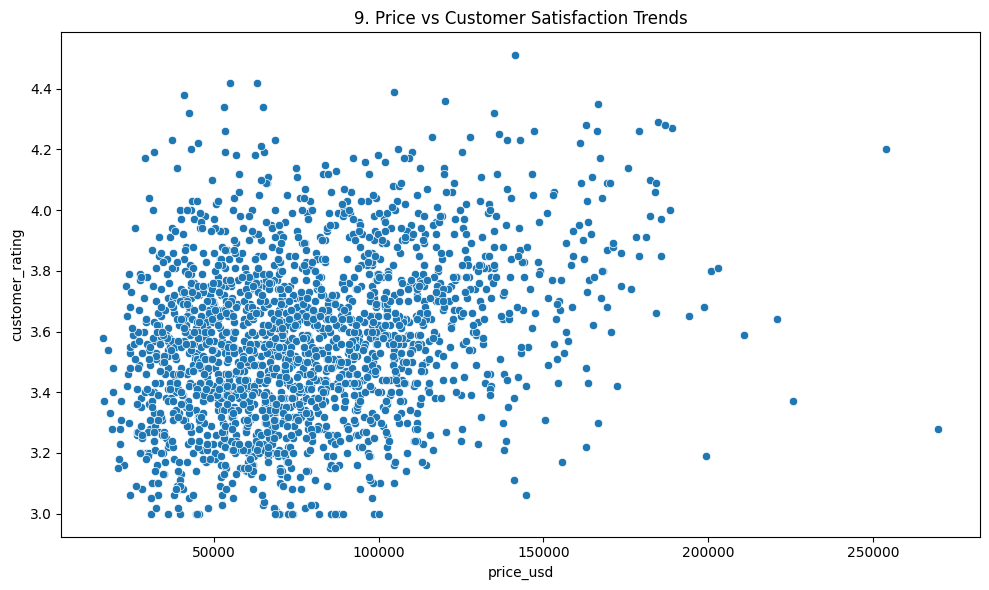

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='price_usd', y='customer_rating', data=df)
plt.title(f'{plot_no}. Price vs Customer Satisfaction Trends')
show_fig()
plot_no += 1

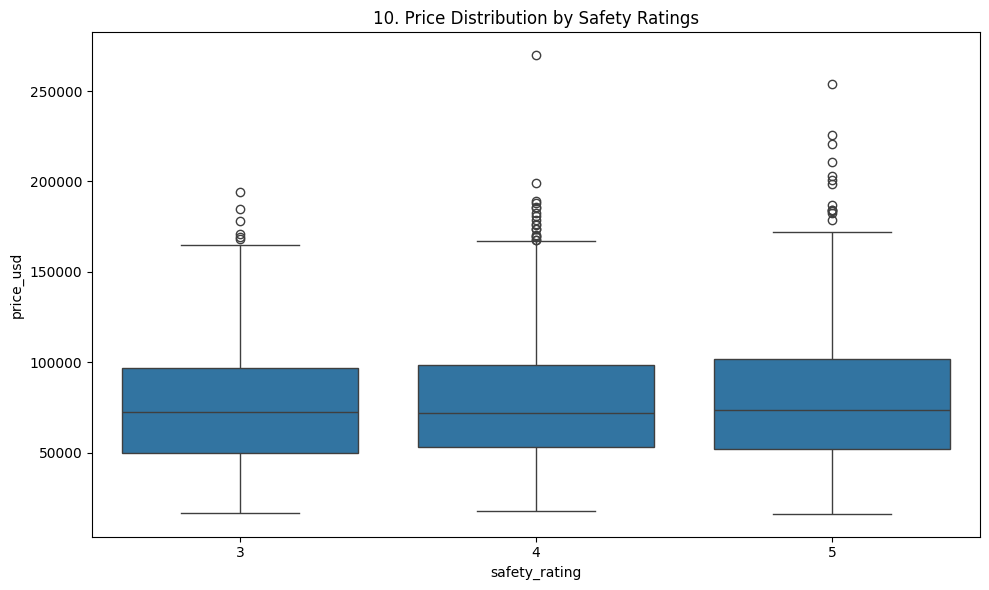

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='safety_rating', y='price_usd', data=df)
plt.title(f'{plot_no}. Price Distribution by Safety Ratings')
show_fig()
plot_no += 1

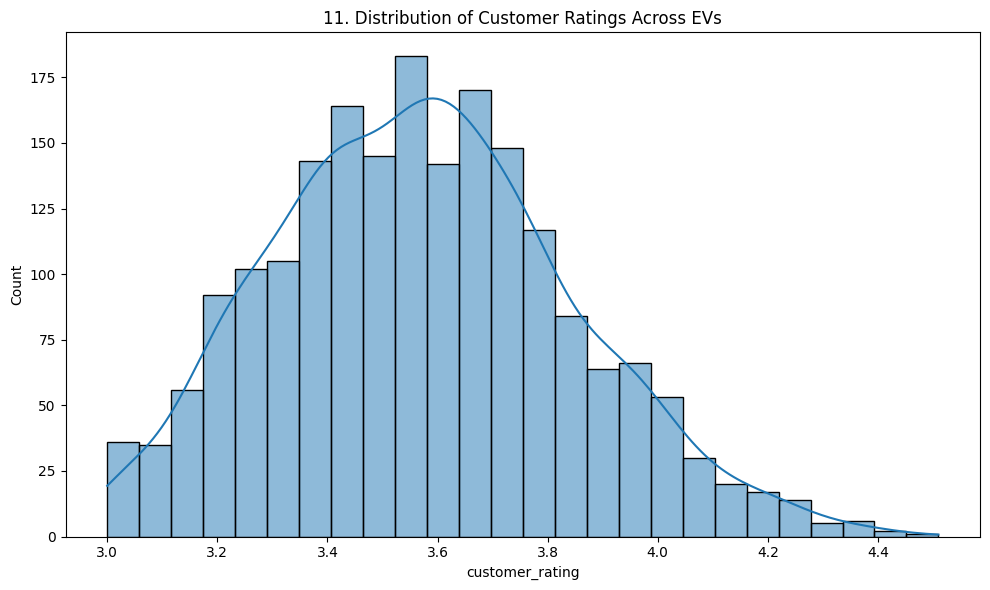

In [23]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['customer_rating'], kde=True)
plt.title(f'{plot_no}. Distribution of Customer Ratings Across EVs')
show_fig()
plot_no += 1

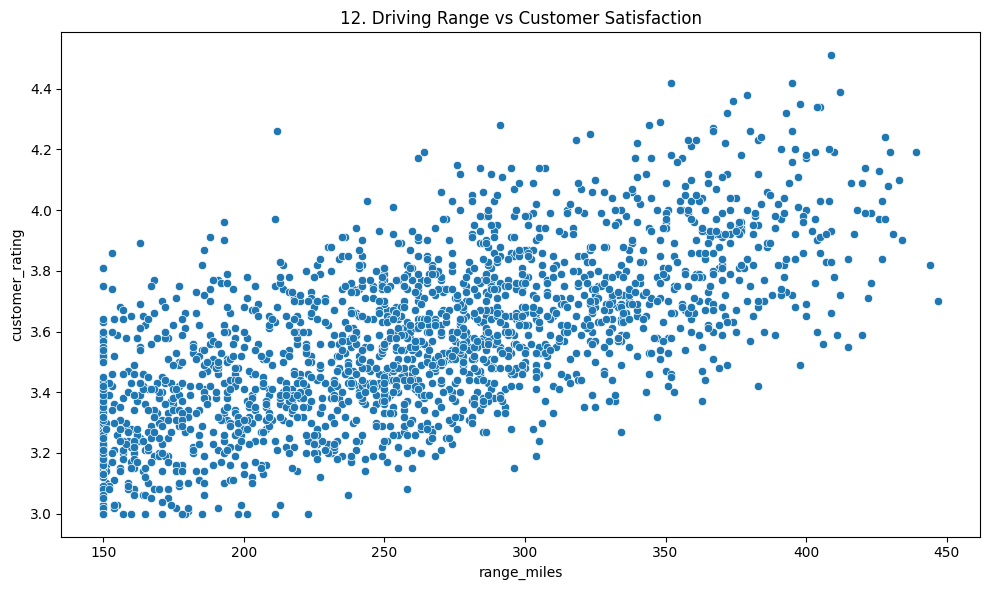

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='range_miles', y='customer_rating', data=df)
plt.title(f'{plot_no}. Driving Range vs Customer Satisfaction')
show_fig()
plot_no += 1

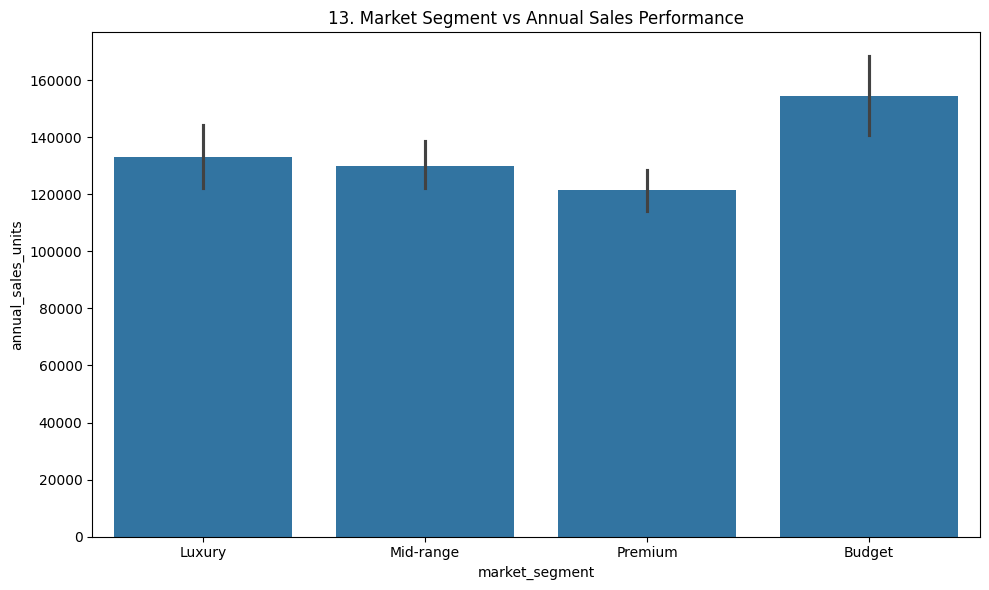

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='market_segment', y='annual_sales_units', data=df)
plt.title(f'{plot_no}. Market Segment vs Annual Sales Performance')
show_fig()
plot_no += 1

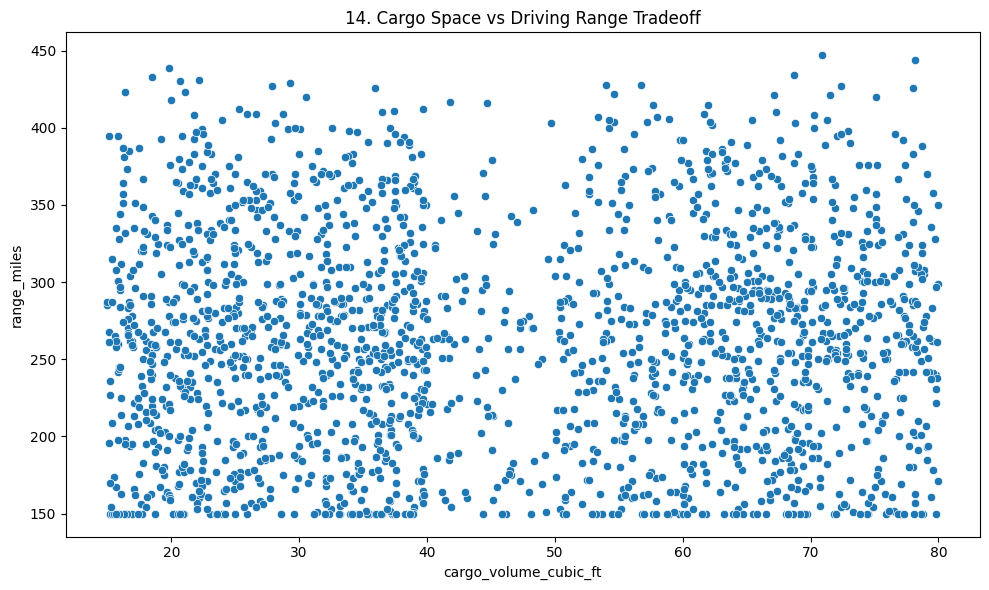

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='cargo_volume_cubic_ft', y='range_miles', data=df)
plt.title(f'{plot_no}. Cargo Space vs Driving Range Tradeoff')
show_fig()
plot_no += 1

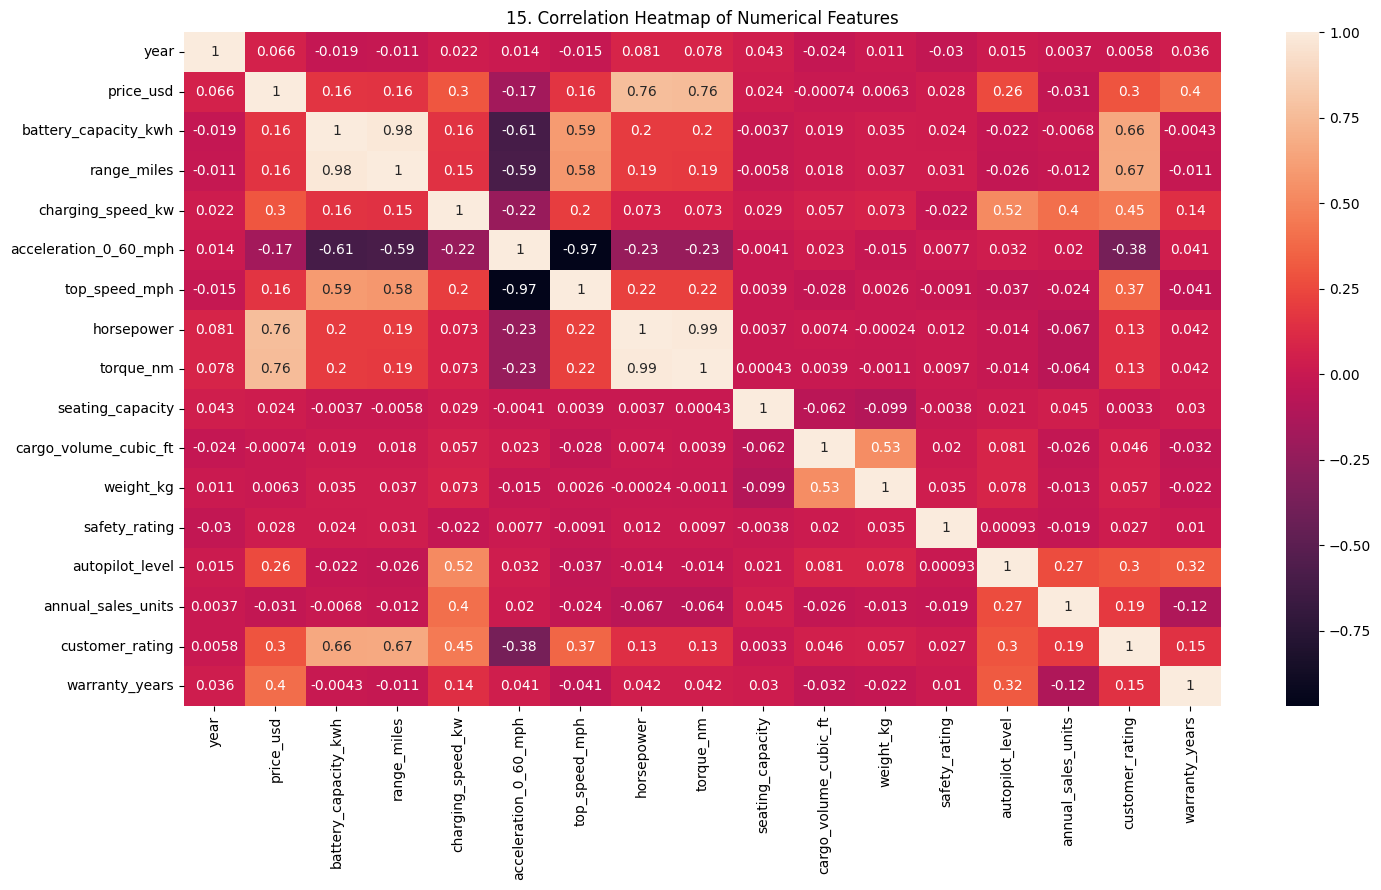

In [27]:
fig = plt.figure(figsize=(15, 9))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

In [28]:
corr

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years
year,1.000000,0.065604,-0.018653,-0.010605,0.022345,0.014385,-0.014974,0.080867,0.078481,0.043233,-0.023846,0.011005,-0.030302,0.015391,0.003734,0.005815,0.035789
price_usd,0.065604,1.000000,0.163565,0.156174,0.302888,-0.172457,0.164290,0.764724,0.759726,0.023512,-0.000737,0.006261,0.027652,0.257110,-0.030502,0.298409,0.396250
battery_capacity_kwh,-0.018653,0.163565,1.000000,0.977859,0.155309,-0.606528,0.592145,0.199032,0.197377,-0.003692,0.018981,0.034911,0.024168,-0.021736,-0.006791,0.658008,-0.004284
range_miles,-0.010605,0.156174,0.977859,1.000000,0.148906,-0.592191,0.577426,0.192405,0.190323,-0.005804,0.018149,0.036884,0.030825,-0.026423,-0.012127,0.668137,-0.010557
charging_speed_kw,0.022345,0.302888,0.155309,0.148906,1.000000,-0.222219,0.200766,0.073125,0.073153,0.028932,0.056504,0.073468,-0.022332,0.519870,0.401654,0.447148,0.135887
acceleration_0_60_mph,0.014385,-0.172457,-0.606528,-0.592191,-0.222219,1.000000,-0.970953,-0.227614,-0.226616,-0.004088,0.022828,-0.015251,0.007723,0.032428,0.019917,-0.377177,0.040619
top_speed_mph,-0.014974,0.164290,0.592145,0.577426,0.200766,-0.970953,1.000000,0.217379,0.216991,0.003859,-0.028282,0.002589,-0.009063,-0.036581,-0.023985,0.366117,-0.041165
horsepower,0.080867,0.764724,0.199032,0.192405,0.073125,-0.227614,0.217379,1.000000,0.991827,0.003683,0.007445,-0.000243,0.012050,-0.014193,-0.067041,0.134986,0.042018
torque_nm,0.078481,0.759726,0.197377,0.190323,0.073153,-0.226616,0.216991,0.991827,1.000000,0.000426,0.003876,-0.001058,0.009741,-0.014091,-0.064073,0.132197,0.042297
seating_capacity,0.043233,0.023512,-0.003692,-0.005804,0.028932,-0.004088,0.003859,0.003683,0.000426,1.000000,-0.062495,-0.098862,-0.003792,0.021340,0.045239,0.003265,0.029833


# Model Training

## select features and target (predict price)

In [29]:
X = df.select_dtypes(include='number').drop(columns=['price_usd'])
y = df['price_usd']

## split dataset

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale features

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## train model

In [32]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## prediction

In [33]:
y_pred = model.predict(X_test_scaled)

## evaluation

In [34]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)

R2 Score: 0.7562213206085314
MSE: 277944089.8403564


## actual vs predicted plot

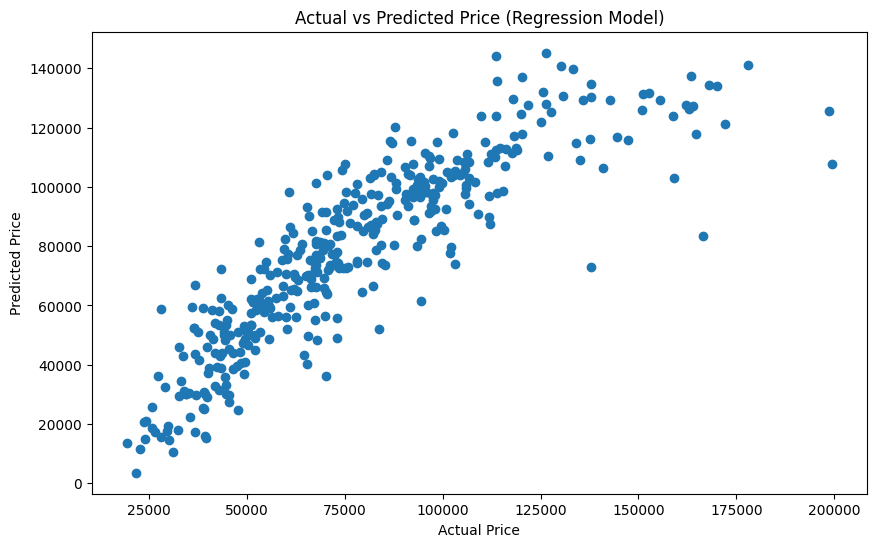

In [35]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Regression Model)")
plt.show()